In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("Unemployment in India.csv")

In [3]:
df.head()

df.info()

df.describe()

df.shape

df.columns

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [4]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [5]:
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [6]:
df["Date"] = pd.to_datetime(df["Date"])

C:\Users\Mozammil\AppData\Local\Temp\ipykernel_18864\936118274.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


In [7]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month_name()

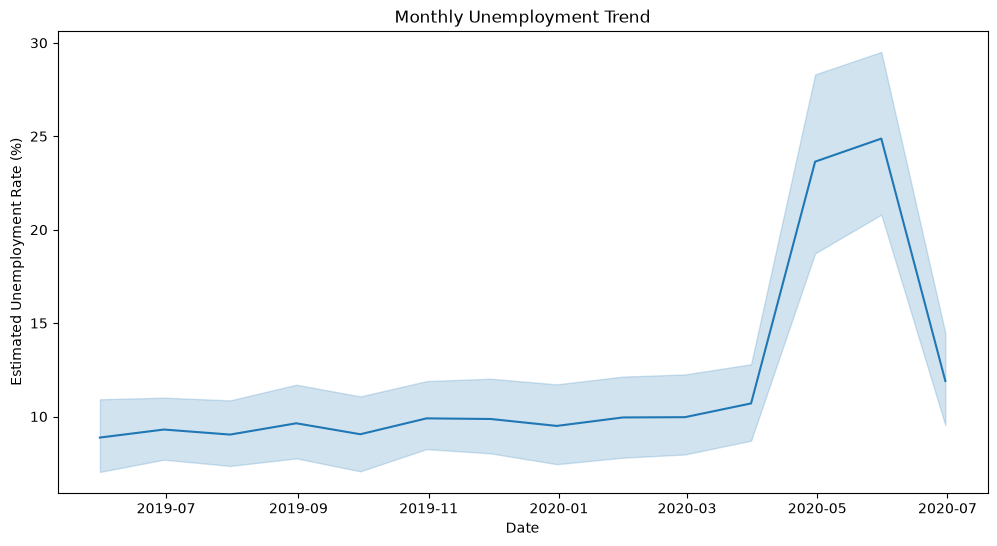

In [8]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x="Date",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Monthly Unemployment Trend")

plt.show()

## Exploratory Data Analysis

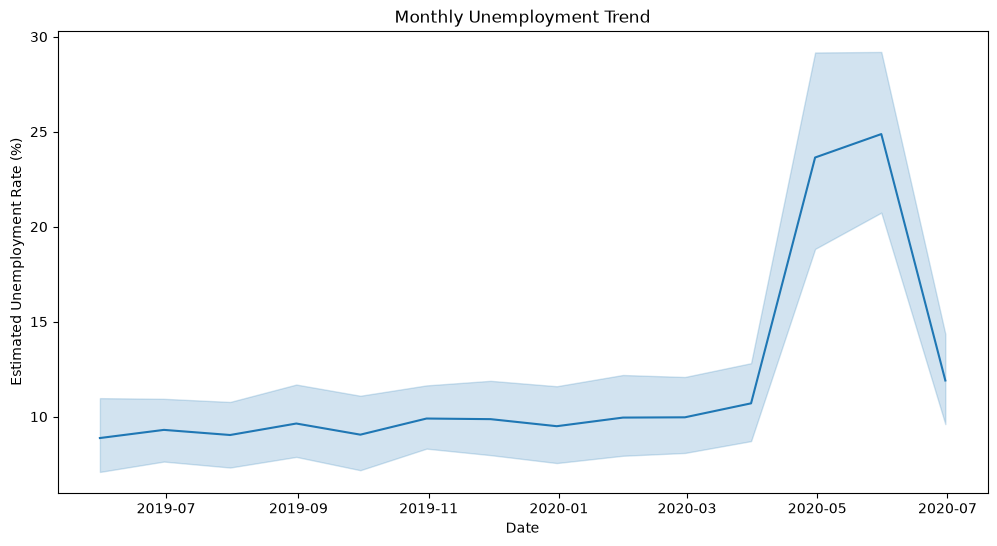

In [9]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x="Date",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Monthly Unemployment Trend")

plt.show()

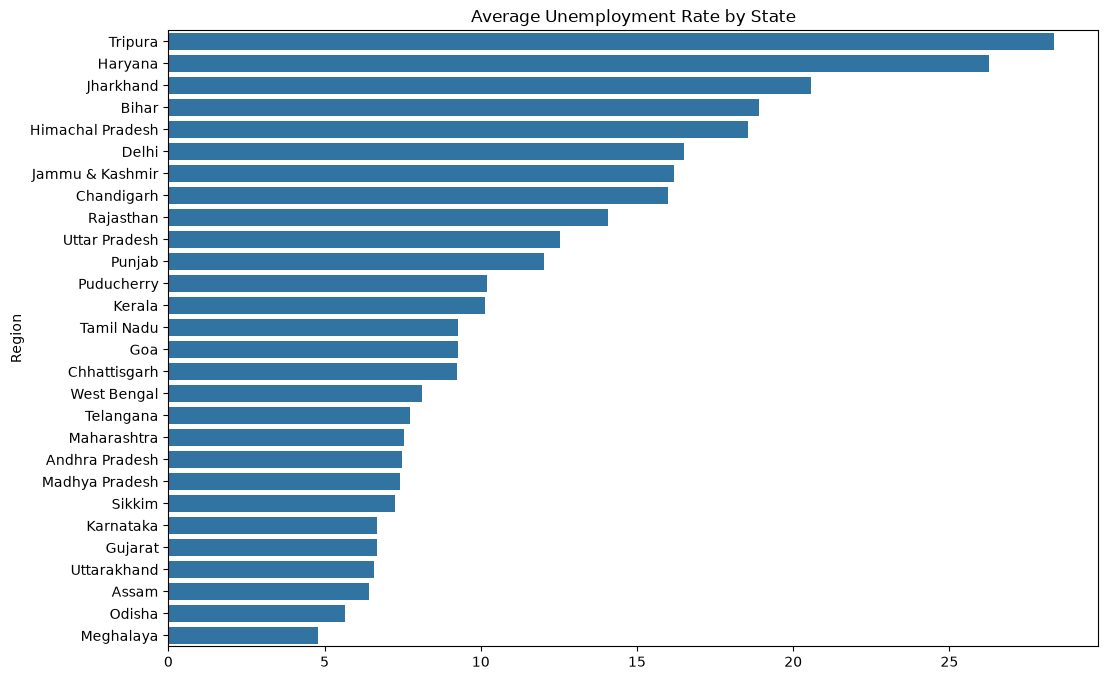

In [10]:
state = df.groupby("Region")[
    "Estimated Unemployment Rate (%)"
].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state.values,
    y=state.index
)

plt.title("Average Unemployment Rate by State")

plt.show()

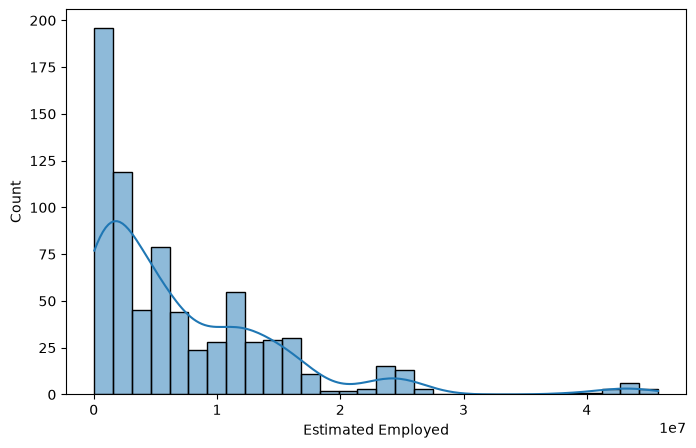

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated Employed"],
    bins=30,
    kde=True
)

plt.show()

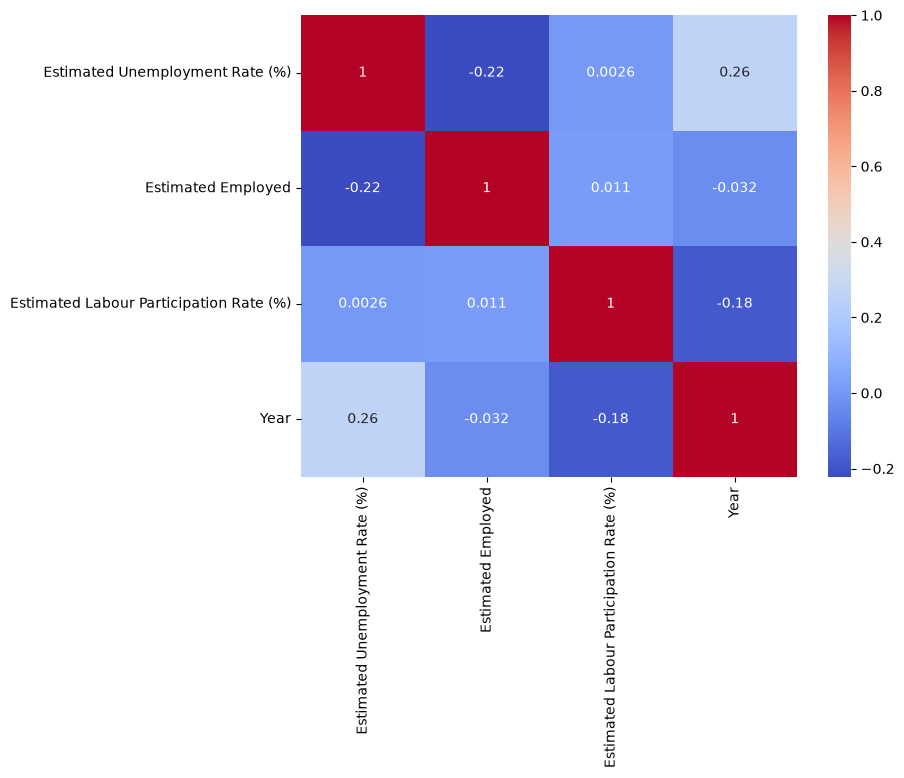

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## COVID-19 Impact Analysis

The nationwide lockdown in India began in March 2020, so comparing unemployment before and after that period helps highlight the pandemic's economic impact.

In [13]:
covid = df[df["Year"] == 2020]

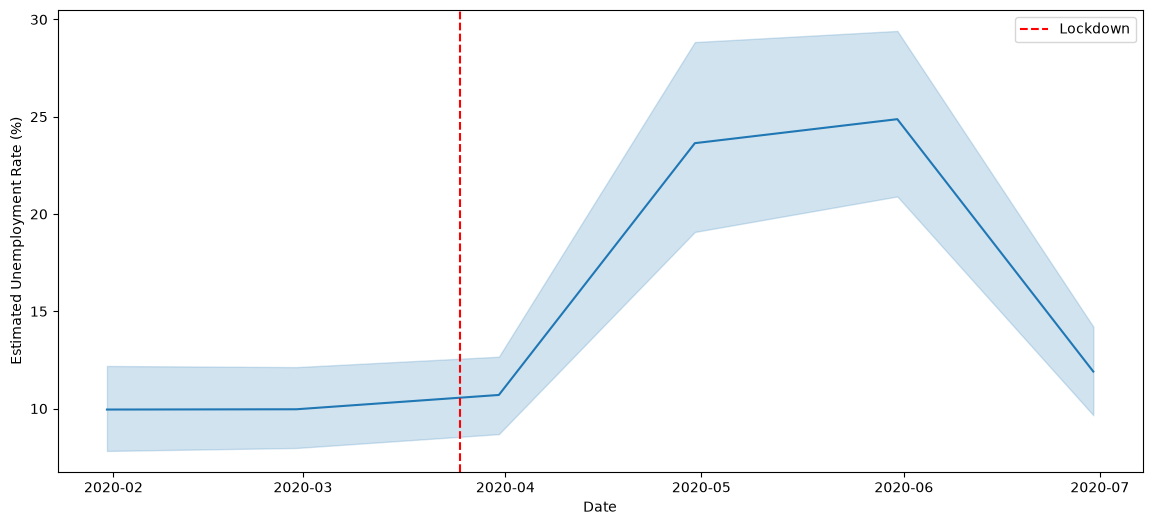

In [14]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=covid,
    x="Date",
    y="Estimated Unemployment Rate (%)"
)

plt.axvline(
    pd.Timestamp("2020-03-25"),
    color="red",
    linestyle="--",
    label="Lockdown"
)

plt.legend()

plt.show()

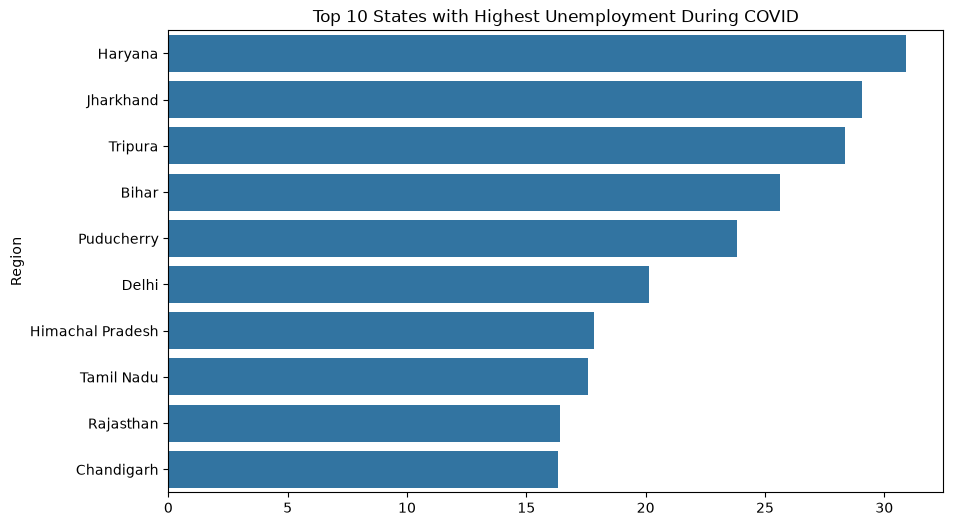

In [15]:
top = covid.groupby("Region")[
    "Estimated Unemployment Rate (%)"
].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top.values,
    y=top.index
)

plt.title("Top 10 States with Highest Unemployment During COVID")

plt.show()

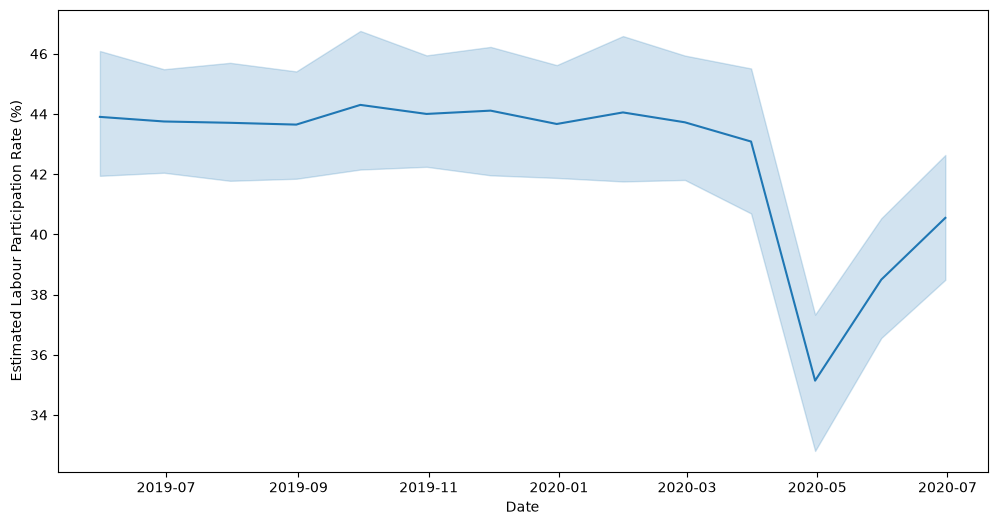

In [16]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x="Date",
    y="Estimated Labour Participation Rate (%)"
)

plt.show()

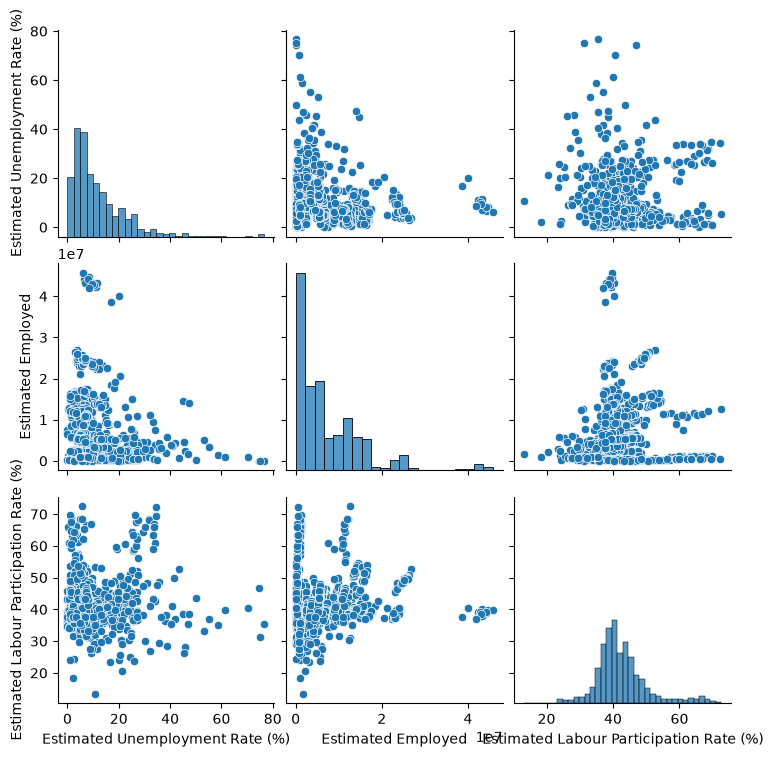

In [17]:
sns.pairplot(df[
[
"Estimated Unemployment Rate (%)",
"Estimated Employed",
"Estimated Labour Participation Rate (%)"
]
])

plt.show()